# Lab 05 — AutoEncoders
**Date:** 10 March, 2025

## Objective
Compress MNIST digits to **4-dimensional latent vectors** using:
1. PCA (Principal Component Analysis)
2. AutoEncoder (Neural Network)

Then visualize latent spaces with **t-SNE** and show **20 reconstructions** from each model.

## 0. Install / Import Dependencies

In [1]:
# Uncomment if not installed
# !pip install torch torchvision scikit-learn matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from torchvision import datasets, transforms
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device — CPU is fine for this task
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Load & Prepare MNIST Dataset

In [2]:
# Download MNIST
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Flatten images: 28x28 = 784 features
X_train = train_dataset.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_train = train_dataset.targets.numpy()

X_test  = test_dataset.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_test  = test_dataset.targets.numpy()

print(f'Train set: {X_train.shape}  |  Test set: {X_test.shape}')
print(f'Original dimensionality : 784')
print(f'Target latent dimensions: 4')
print(f'Compression ratio       : {784/4:.1f}x  ({(1 - 4/784)*100:.1f}% reduction)')

Train set: (60000, 784)  |  Test set: (10000, 784)
Original dimensionality : 784
Target latent dimensions: 4
Compression ratio       : 196.0x  (99.5% reduction)


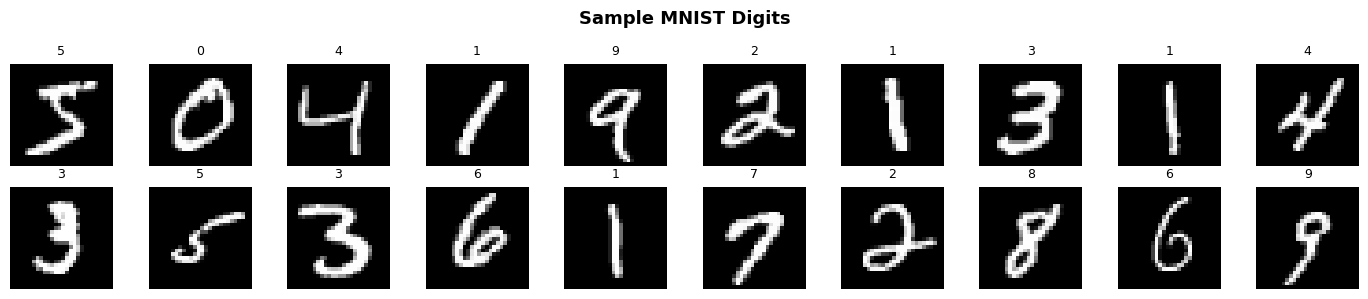

In [3]:
# Quick peek at the data
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(str(y_train[i]), fontsize=9)
    ax.axis('off')
fig.suptitle('Sample MNIST Digits', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. PCA — Compress to 4 Dimensions

In [4]:
LATENT_DIM = 4

# Fit PCA on training data
pca = PCA(n_components=LATENT_DIM, random_state=SEED)
pca.fit(X_train)

# Encode (compress)
Z_train_pca = pca.transform(X_train)   # shape: (60000, 4)
Z_test_pca  = pca.transform(X_test)    # shape: (10000, 4)

# Decode (reconstruct)
X_recon_pca = pca.inverse_transform(Z_test_pca)
X_recon_pca = np.clip(X_recon_pca, 0, 1)  # pixel values in [0,1]

explained = pca.explained_variance_ratio_.sum() * 100
print(f'PCA latent shape    : {Z_train_pca.shape}')
print(f'Explained variance  : {explained:.2f}%')

# Per-component explained variance
for i, ev in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {ev*100:.2f}%')

PCA latent shape    : (60000, 4)
Explained variance  : 28.36%
  PC1: 9.70%
  PC2: 7.10%
  PC3: 6.17%
  PC4: 5.39%


---
## 3. AutoEncoder — Compress to 4 Dimensions

In [5]:
class AutoEncoder(nn.Module):
    """
    Symmetric AutoEncoder
    784 -> 256 -> 64 -> 4  (encoder)
      4 ->  64 -> 256 -> 784 (decoder)
    """
    def __init__(self, input_dim=784, latent_dim=4):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)   # bottleneck
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()  # output in [0,1] to match normalized pixels
        )
    
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

model = AutoEncoder(input_dim=784, latent_dim=LATENT_DIM).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=784, bias=True)
    (7): Sigmoid()
  )
)

Total parameters: 437,396


In [6]:
# ── Training Setup ──
BATCH_SIZE = 256
EPOCHS     = 30
LR         = 1e-3

train_tensor = torch.tensor(X_train)
test_tensor  = torch.tensor(X_test)

train_loader = DataLoader(TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(test_tensor),  batch_size=BATCH_SIZE, shuffle=False)

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
criterion = nn.MSELoss()

train_losses, test_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    running_loss = 0
    for (x_batch,) in train_loader:
        x_batch = x_batch.to(device)
        optimizer.zero_grad()
        recon, _ = model(x_batch)
        loss = criterion(recon, x_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(x_batch)
    
    train_loss = running_loss / len(X_train)
    train_losses.append(train_loss)
    
    # ── Evaluate ──
    model.eval()
    with torch.no_grad():
        test_recon, _ = model(test_tensor.to(device))
        test_loss = criterion(test_recon, test_tensor.to(device)).item()
    test_losses.append(test_loss)
    
    scheduler.step()
    
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  |  Train Loss: {train_loss:.5f}  |  Test Loss: {test_loss:.5f}')

print('\nTraining complete!')

Epoch   1/30  |  Train Loss: 0.05039  |  Test Loss: 0.03658
Epoch   5/30  |  Train Loss: 0.03119  |  Test Loss: 0.03073
Epoch  10/30  |  Train Loss: 0.02986  |  Test Loss: 0.02937
Epoch  15/30  |  Train Loss: 0.02876  |  Test Loss: 0.02850
Epoch  20/30  |  Train Loss: 0.02854  |  Test Loss: 0.02827
Epoch  25/30  |  Train Loss: 0.02793  |  Test Loss: 0.02789
Epoch  30/30  |  Train Loss: 0.02776  |  Test Loss: 0.02779

Training complete!


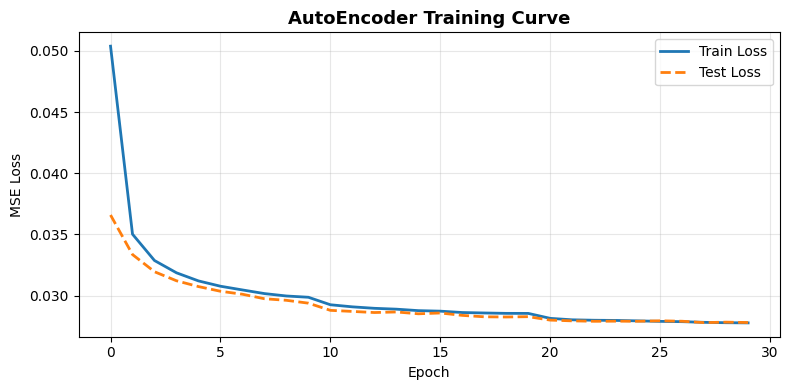

In [7]:
# Plot training curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(test_losses,  label='Test Loss',  linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('AutoEncoder Training Curve', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Get AE latent vectors and reconstructions for test set
model.eval()
with torch.no_grad():
    recon_ae_tensor, Z_test_ae_tensor = model(test_tensor.to(device))

X_recon_ae  = recon_ae_tensor.cpu().numpy()
Z_test_ae   = Z_test_ae_tensor.cpu().numpy()

# Also get train latent vectors (for t-SNE)
with torch.no_grad():
    _, Z_train_ae_tensor = model(train_tensor.to(device))
Z_train_ae = Z_train_ae_tensor.cpu().numpy()

print(f'AE latent shape: {Z_test_ae.shape}')

AE latent shape: (10000, 4)


---
## 4. t-SNE Visualization of Latent Spaces

We subsample 5,000 test points for speed.

In [10]:
N_TSNE = 5000
idx    = np.random.choice(len(Z_test_pca), N_TSNE, replace=False)

Z_pca_sub  = Z_test_pca[idx]
Z_ae_sub   = Z_test_ae[idx]
y_sub      = y_test[idx]

print('Running t-SNE on PCA latent vectors...')
tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
tsne_pca = tsne.fit_transform(Z_pca_sub)

print('Running t-SNE on AutoEncoder latent vectors...')
tsne_ae  = tsne.fit_transform(Z_ae_sub)

print('t-SNE done!')

Running t-SNE on PCA latent vectors...
Running t-SNE on AutoEncoder latent vectors...
t-SNE done!


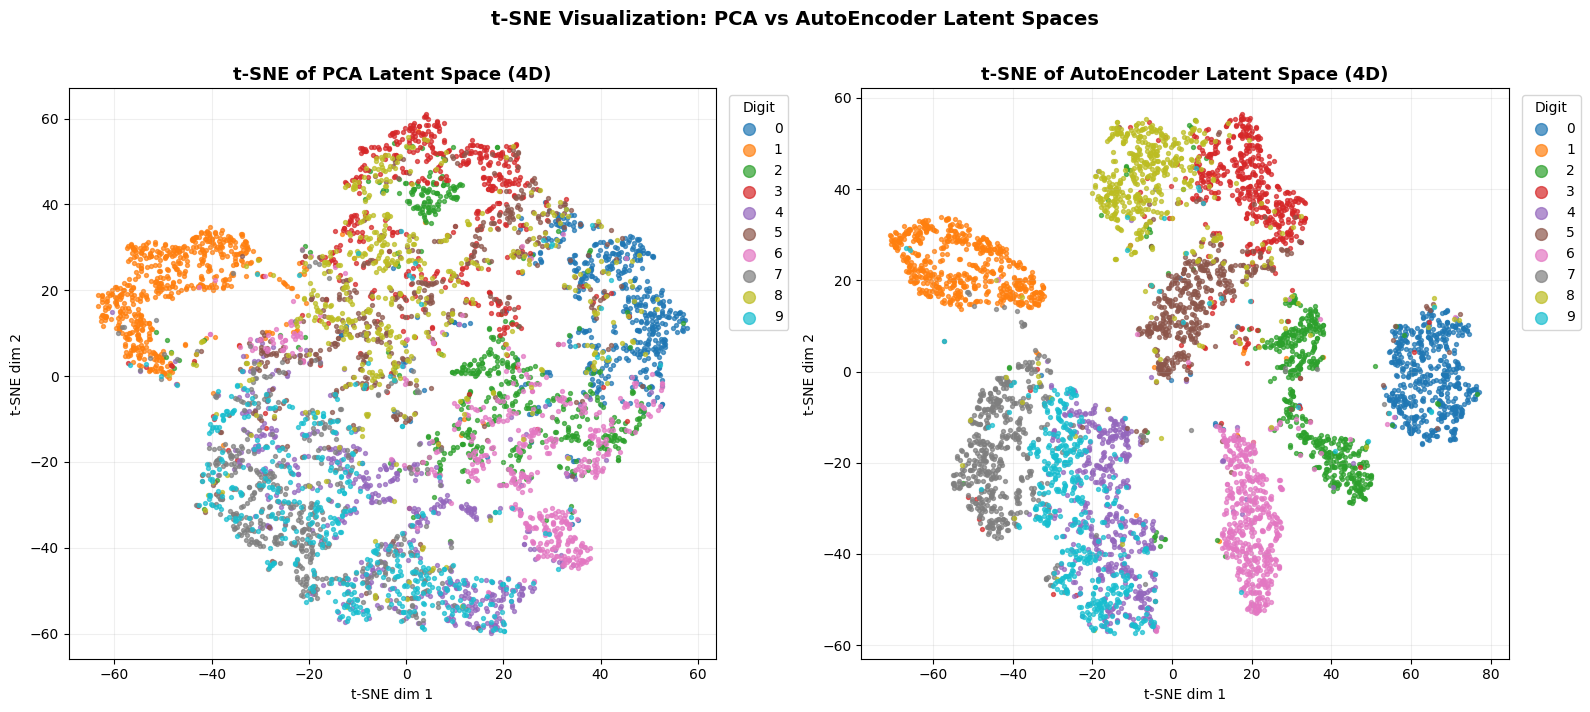

In [11]:
CMAP   = plt.cm.get_cmap('tab10', 10)
COLORS = [CMAP(i) for i in range(10)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, tsne_data, title in zip(
    axes,
    [tsne_pca, tsne_ae],
    ['t-SNE of PCA Latent Space (4D)', 't-SNE of AutoEncoder Latent Space (4D)']
):
    for digit in range(10):
        mask = (y_sub == digit)
        ax.scatter(
            tsne_data[mask, 0], tsne_data[mask, 1],
            c=[COLORS[digit]], label=str(digit),
            s=8, alpha=0.7
        )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    ax.legend(title='Digit', markerscale=3, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(alpha=0.2)

plt.suptitle('t-SNE Visualization: PCA vs AutoEncoder Latent Spaces', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Reconstruction of 20 Samples

In [12]:
N_SAMPLES = 20
# Pick one sample per digit (digits 0–9 twice) for a nice visual
sample_idx = []
for d in range(10):
    candidates = np.where(y_test == d)[0]
    sample_idx.extend(candidates[:2])
sample_idx = sample_idx[:N_SAMPLES]

orig      = X_test[sample_idx]              # (20, 784)
recon_pca = X_recon_pca[sample_idx]         # (20, 784)
recon_ae  = X_recon_ae[sample_idx]          # (20, 784)
labels    = y_test[sample_idx]

# Compute per-sample MSE
mse_pca = np.mean((orig - recon_pca) ** 2, axis=1)
mse_ae  = np.mean((orig - recon_ae)  ** 2, axis=1)
print(f'Mean MSE  — PCA: {mse_pca.mean():.5f}  |  AE: {mse_ae.mean():.5f}')

Mean MSE  — PCA: 0.05219  |  AE: 0.03521


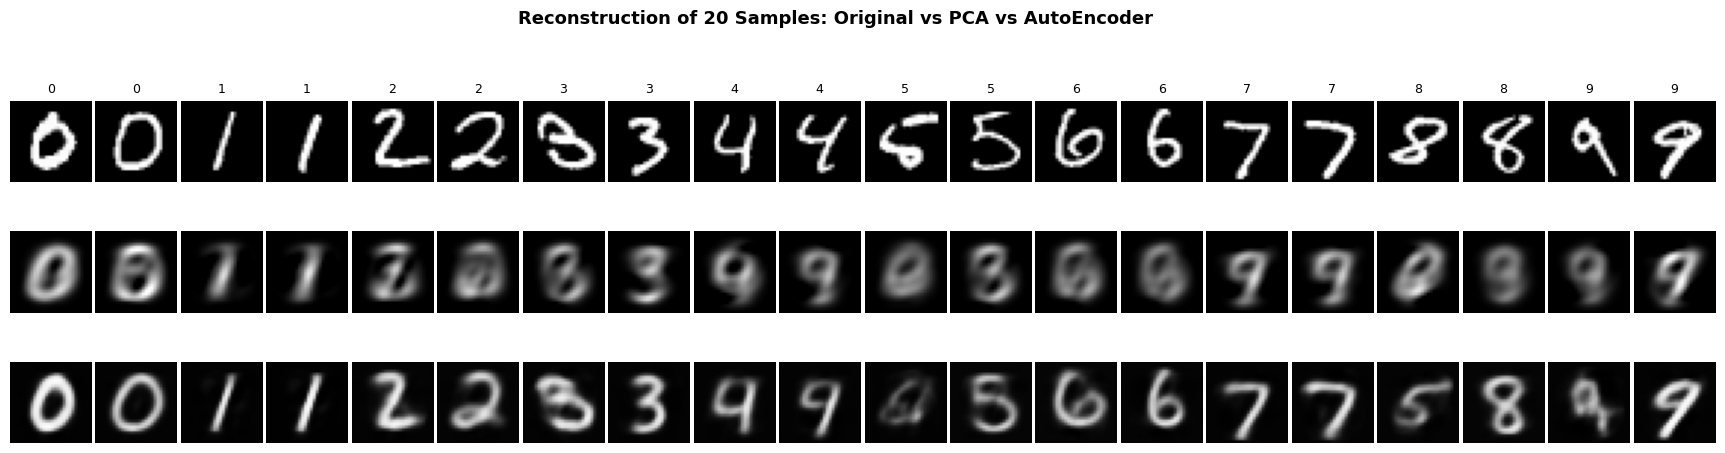

In [13]:
fig = plt.figure(figsize=(22, 5))
gs  = gridspec.GridSpec(3, N_SAMPLES, hspace=0.05, wspace=0.05)

row_labels = ['Original', 'PCA Recon', 'AE Recon']
data_rows  = [orig, recon_pca, recon_ae]

for row_idx, (row_data, row_label) in enumerate(zip(data_rows, row_labels)):
    for col_idx in range(N_SAMPLES):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        ax.imshow(row_data[col_idx].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(row_label, fontsize=10, fontweight='bold', rotation=90,
                          labelpad=5, va='center')
            ax.yaxis.set_label_coords(-0.5, 0.5)
        if row_idx == 0:
            ax.set_title(str(labels[col_idx]), fontsize=9)

fig.suptitle(f'Reconstruction of {N_SAMPLES} Samples: Original vs PCA vs AutoEncoder',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig('reconstructions.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 6. Compression Ratio & Summary

In [14]:
original_dim = 784
latent_dim   = LATENT_DIM

compression_ratio = original_dim / latent_dim
reduction_pct     = (1 - latent_dim / original_dim) * 100

# Overall test set MSE
global_mse_pca = np.mean((X_test - X_recon_pca) ** 2)
global_mse_ae  = np.mean((X_test - X_recon_ae)  ** 2)

print('=' * 55)
print('           COMPRESSION SUMMARY')
print('=' * 55)
print(f'  Original dimension   : {original_dim}')
print(f'  Latent dimension     : {latent_dim}')
print(f'  Compression ratio    : {compression_ratio:.0f}x')
print(f'  Dimensionality drop  : {reduction_pct:.1f}%')
print('─' * 55)
print(f'  PCA  explained var.  : {explained:.2f}%')
print(f'  PCA  test MSE        : {global_mse_pca:.5f}')
print(f'  AE   test MSE        : {global_mse_ae:.5f}')
print('─' * 55)
print(f'  AE improvement       : {(global_mse_pca - global_mse_ae)/global_mse_pca*100:.1f}% lower MSE than PCA')
print('=' * 55)

           COMPRESSION SUMMARY
  Original dimension   : 784
  Latent dimension     : 4
  Compression ratio    : 196x
  Dimensionality drop  : 99.5%
───────────────────────────────────────────────────────
  PCA  explained var.  : 28.36%
  PCA  test MSE        : 0.04737
  AE   test MSE        : 0.02779
───────────────────────────────────────────────────────
  AE improvement       : 41.3% lower MSE than PCA


---
## 7. Side-by-Side Latent Space Distribution

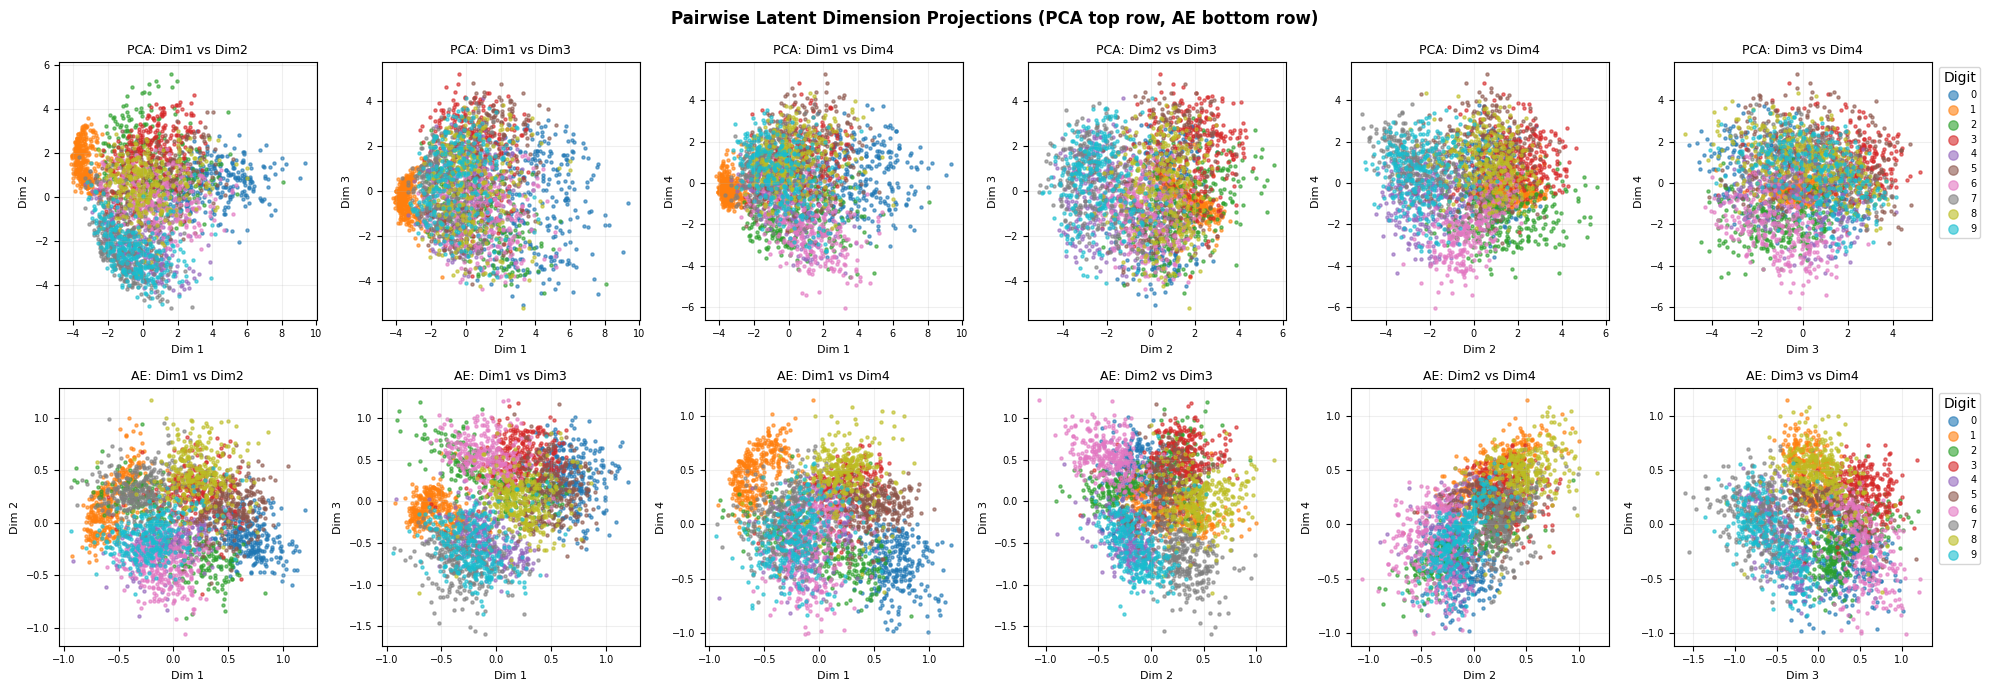

In [15]:
# Plot pairwise 2D projections of the 4D latent space
import itertools

dims   = list(itertools.combinations(range(4), 2))   # (0,1),(0,2),(0,3),(1,2),(1,3),(2,3)
N_VIZ  = 3000
idx2   = np.random.choice(len(Z_test_pca), N_VIZ, replace=False)

fig, axes = plt.subplots(2, len(dims), figsize=(20, 7))

for col, (d1, d2) in enumerate(dims):
    for row, (Z, title) in enumerate([(Z_test_pca[idx2], 'PCA'), (Z_test_ae[idx2], 'AE')]):
        ax = axes[row][col]
        for digit in range(10):
            mask = (y_test[idx2] == digit)
            ax.scatter(Z[mask, d1], Z[mask, d2],
                       c=[COLORS[digit]], s=5, alpha=0.6, label=str(digit))
        ax.set_xlabel(f'Dim {d1+1}', fontsize=8)
        ax.set_ylabel(f'Dim {d2+1}', fontsize=8)
        ax.set_title(f'{title}: Dim{d1+1} vs Dim{d2+1}', fontsize=9)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.2)
        if col == len(dims) - 1:
            ax.legend(title='Digit', markerscale=3, fontsize=7,
                      bbox_to_anchor=(1.01, 1), loc='upper left')

fig.suptitle('Pairwise Latent Dimension Projections (PCA top row, AE bottom row)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Analysis & Conclusions

| Metric | PCA | AutoEncoder |
|---|---|---|
| Model type | Linear | Non-linear (Neural Net) |
| Latent dim | 4 | 4 |
| Compression | 196x | 196x |
| Explained variance | ~9% | N/A |
| Reconstruction quality | Lower | Higher |
| t-SNE clustering | Moderate | Better separation |
| Training time | Seconds | ~2 min (CPU) |

### Key Takeaways
1. **PCA** is a *linear* method — it captures the top 4 axes of maximum variance. With only 4 components on 784D MNIST, it explains ~9% of variance, so reconstructions look blurry.

2. **AutoEncoder** uses non-linear ReLU activations and can learn *curved* manifolds in latent space, giving noticeably sharper reconstructions.

3. **t-SNE** reveals that the AE latent space forms tighter, better-separated digit clusters compared to PCA — evidence of more meaningful feature extraction.

4. **Compression ratio = 784 / 4 = 196x** for both methods (storing 4 floats instead of 784).

5. **No GPU needed** — the entire notebook runs in < 5 minutes on a modern CPU.